# 02 — Utilization Analysis
Top DRGs by volume and cost, geographic variation by state, and physician service patterns.

**Inputs:** `data/processed/inpatient_clean.csv`, `data/processed/physician_clean.csv`  
**Outputs:** Figures saved to `figures/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0F0F14',
    'axes.facecolor': '#0F0F14',
    'axes.edgecolor': '#2A2A35',
    'axes.labelcolor': '#E2E0E6',
    'text.color': '#E2E0E6',
    'xtick.color': '#9894A8',
    'ytick.color': '#9894A8',
    'grid.color': '#1E1E28',
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 150
})

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')
FIGURES.mkdir(parents=True, exist_ok=True)

INDIGO = '#818CF8'
PINK = '#F472B6'
GREEN = '#10B981'
AMBER = '#F59E0B'
BLUE = '#3B82F6'

---
## 1. Load processed data

In [2]:
inp = pd.read_csv(PROCESSED / 'inpatient_clean.csv', dtype={'provider_zip': str})
print(f'Inpatient: {inp.shape}')

phy = pd.read_csv(
    PROCESSED / 'physician_clean.csv',
    dtype={'provider_zip': str, 'hcpcs_code': str},
    low_memory=False
)
print(f'Physician: {phy.shape}')

Inpatient: (145742, 16)


Physician: (9755020, 24)


---
## 2. Top 15 DRGs by discharge volume

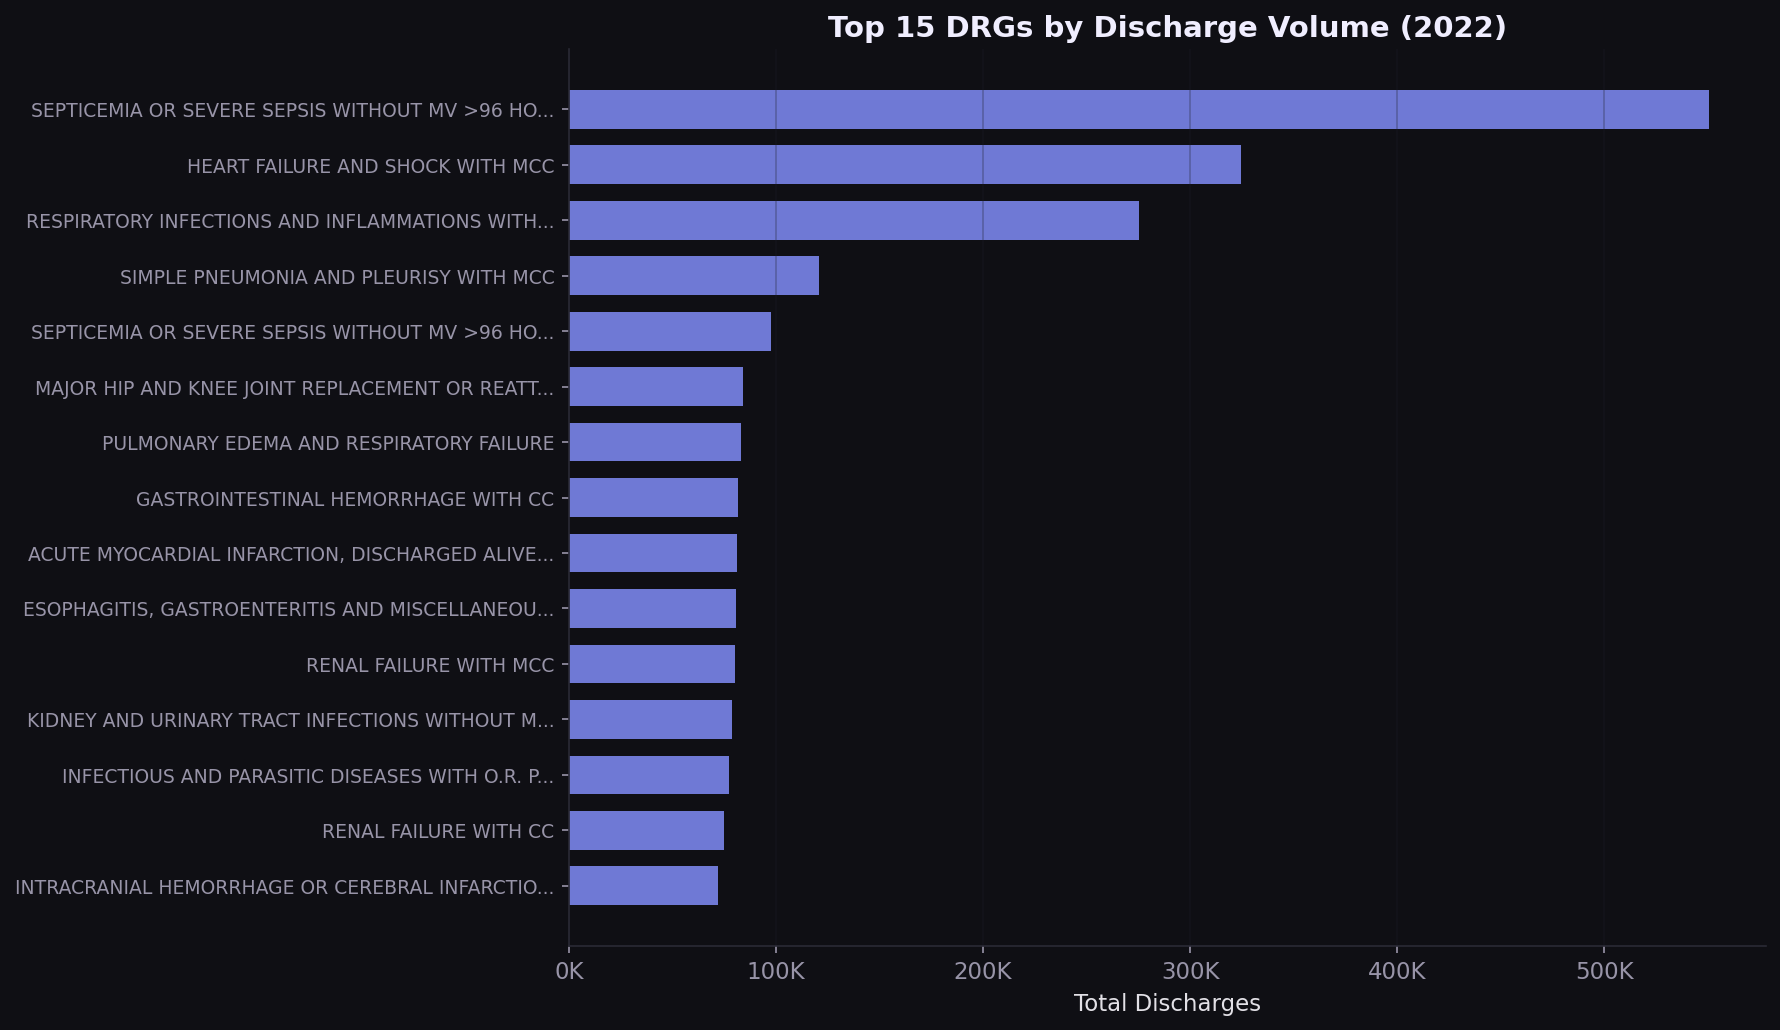

In [3]:
drg_vol = (
    inp.groupby('drg_desc')['total_discharges']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
# Shorten labels: take first 45 chars
labels = [d[:45] + '...' if len(d) > 45 else d for d in drg_vol.index]
bars = ax.barh(range(len(drg_vol)), drg_vol.values, color=INDIGO, alpha=0.85, height=0.7)
ax.set_yticks(range(len(drg_vol)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Discharges')
ax.set_title('Top 15 DRGs by Discharge Volume (2022)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'top15_drg_volume.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Top 15 DRGs by average Medicare payment

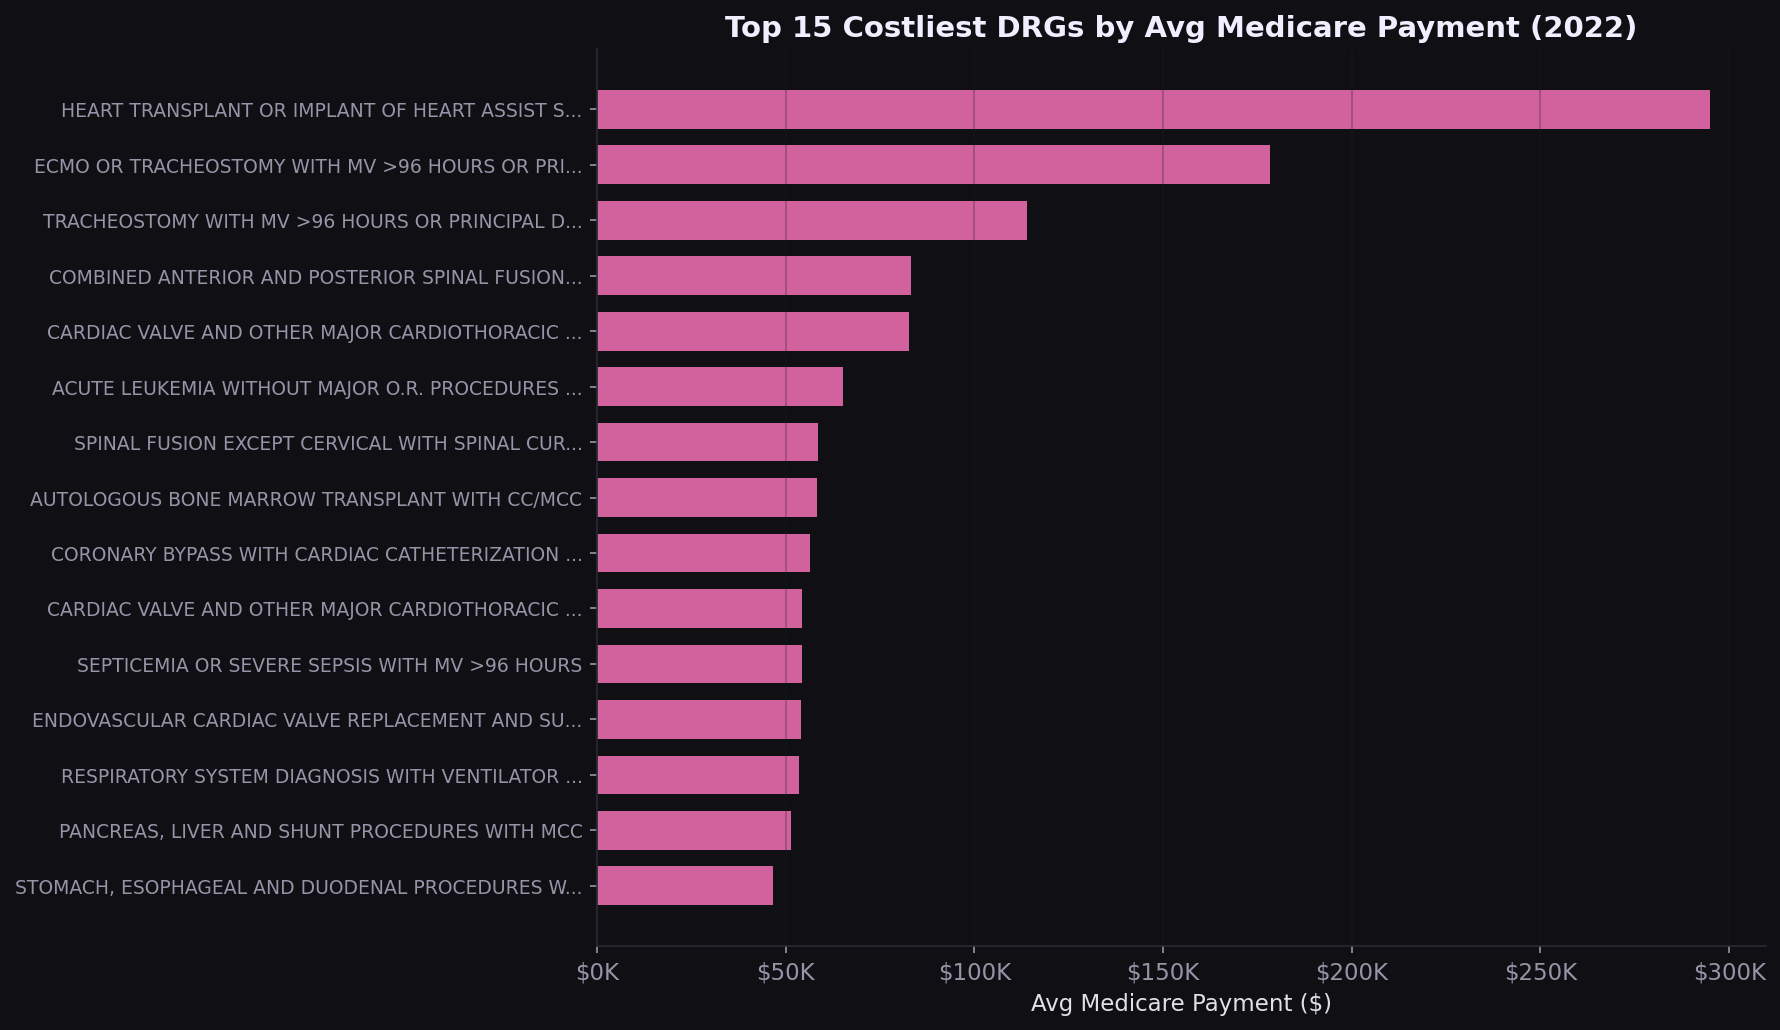

In [4]:
drg_cost = (
    inp.groupby('drg_desc')
    .agg(avg_payment=('avg_medicare_payments', 'mean'), total_vol=('total_discharges', 'sum'))
    .query('total_vol >= 1000')
    .sort_values('avg_payment', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [d[:45] + '...' if len(d) > 45 else d for d in drg_cost.index]
bars = ax.barh(range(len(drg_cost)), drg_cost['avg_payment'], color=PINK, alpha=0.85, height=0.7)
ax.set_yticks(range(len(drg_cost)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Avg Medicare Payment ($)')
ax.set_title('Top 15 Costliest DRGs by Avg Medicare Payment (2022)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'top15_drg_cost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Charges vs. Medicare payments — markup spread by DRG

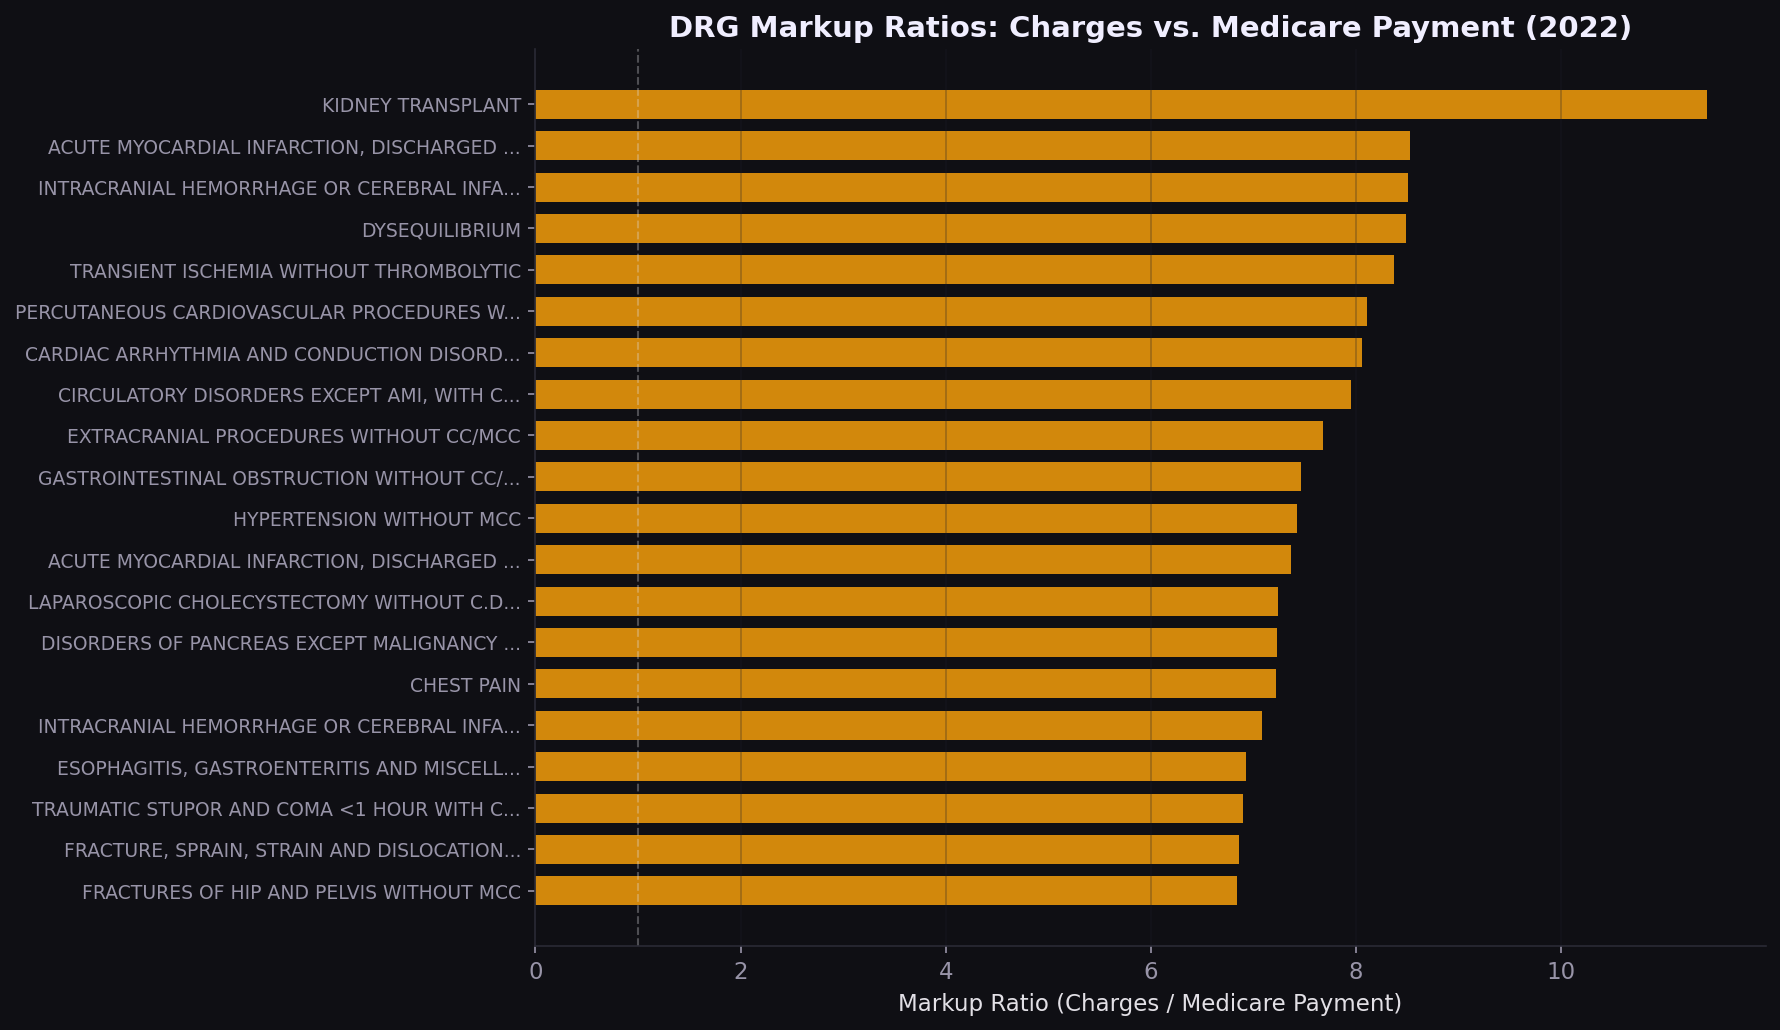

In [5]:
drg_markup = (
    inp.groupby('drg_desc')
    .agg(
        avg_charges=('avg_covered_charges', 'mean'),
        avg_payment=('avg_medicare_payments', 'mean'),
        total_vol=('total_discharges', 'sum')
    )
    .query('total_vol >= 5000')
    .assign(markup=lambda d: d['avg_charges'] / d['avg_payment'])
    .sort_values('markup', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
labels = [d[:40] + '...' if len(d) > 40 else d for d in drg_markup.index]
ax.barh(range(len(drg_markup)), drg_markup['markup'], color=AMBER, alpha=0.85, height=0.7)
ax.set_yticks(range(len(drg_markup)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Markup Ratio (Charges / Medicare Payment)')
ax.set_title('DRG Markup Ratios: Charges vs. Medicare Payment (2022)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.axvline(x=1, color='#E2E0E6', linestyle='--', alpha=0.3, linewidth=1)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'drg_markup_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Geographic variation — discharges and payment by state

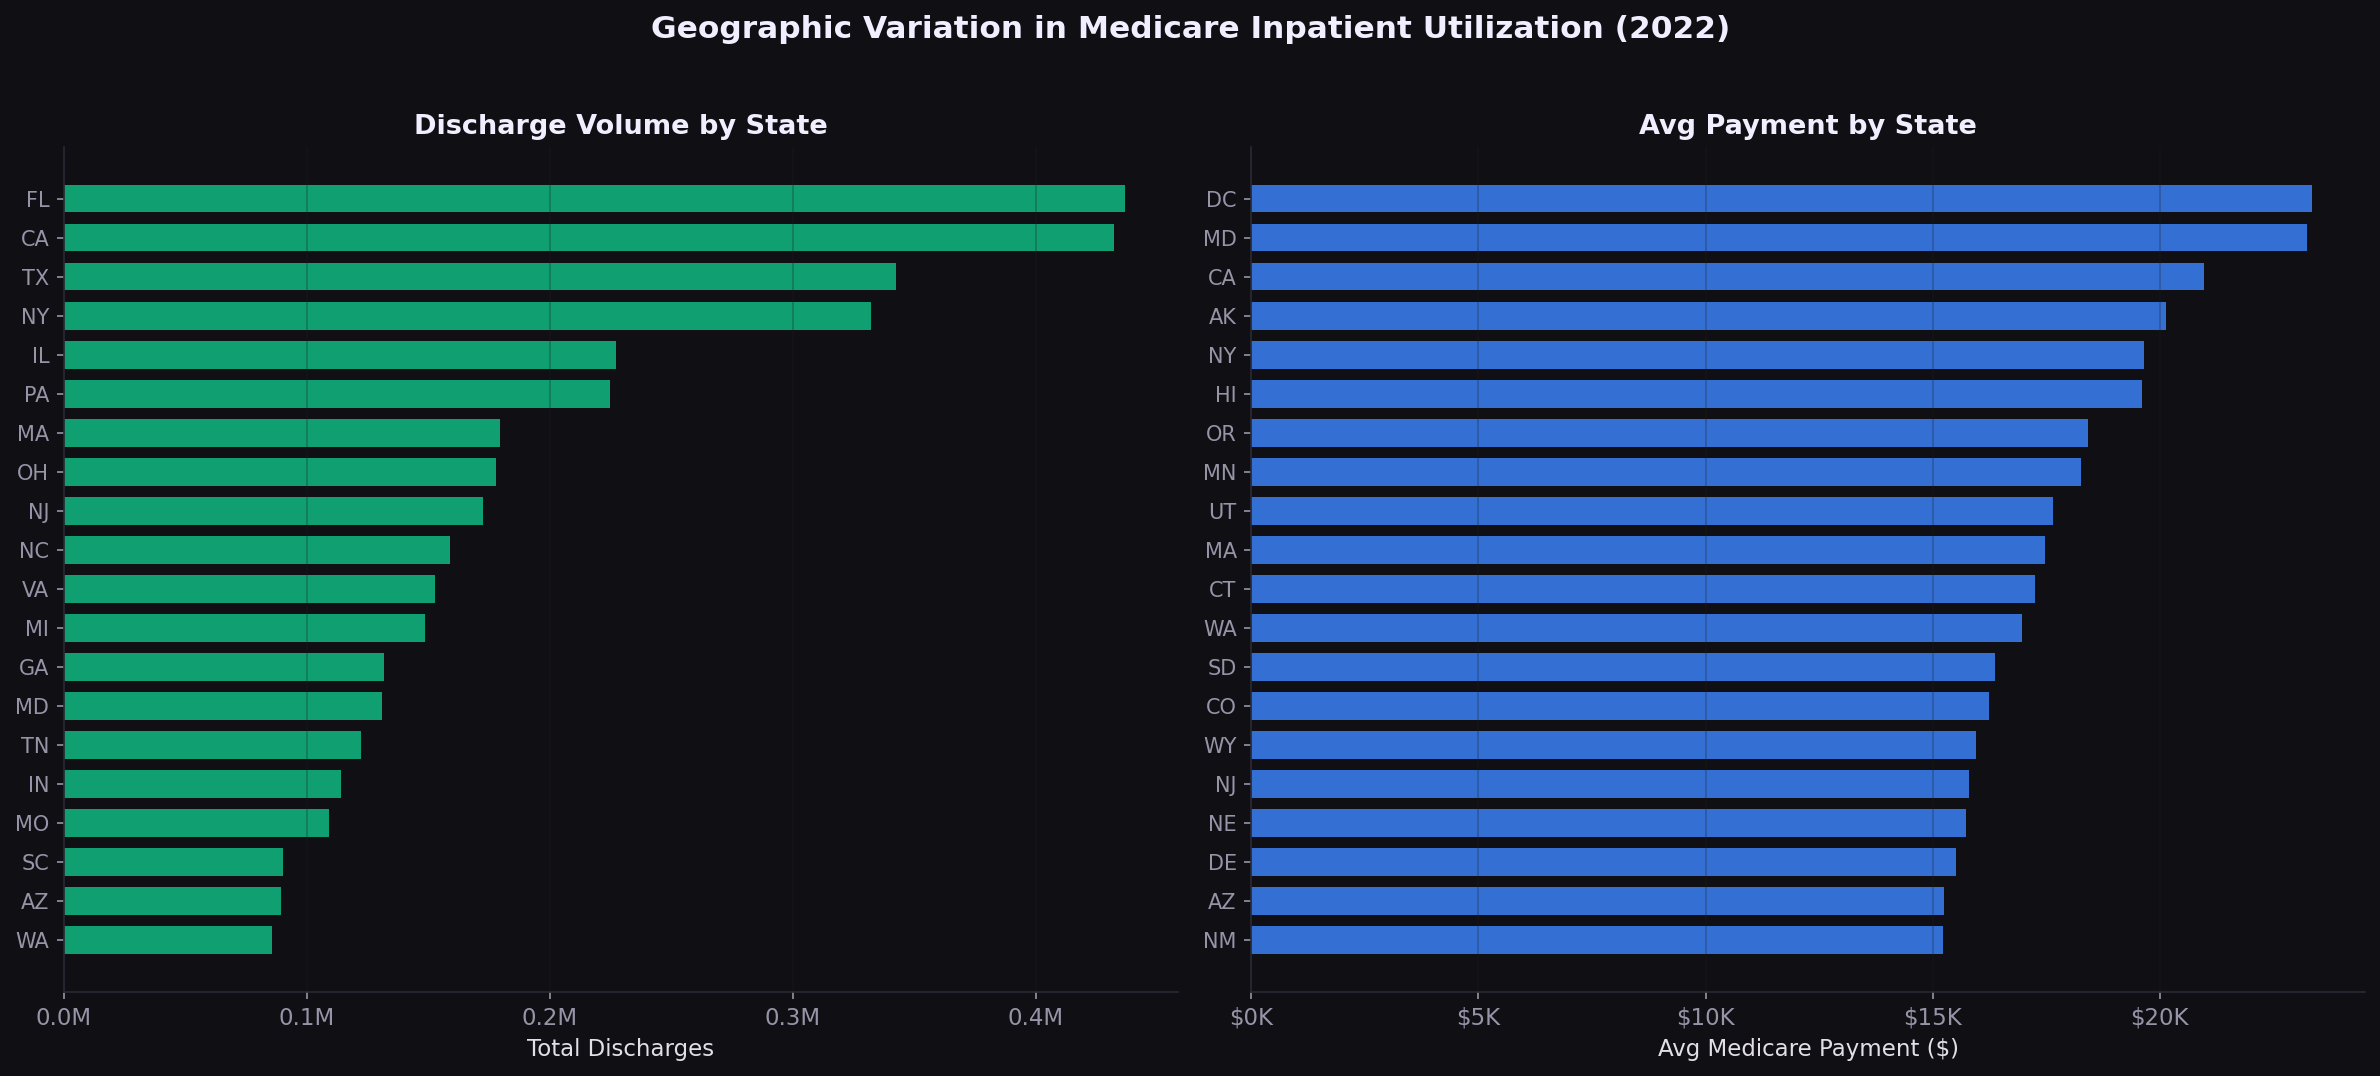

In [6]:
state_agg = (
    inp.groupby('provider_state')
    .agg(
        total_discharges=('total_discharges', 'sum'),
        avg_payment=('avg_medicare_payments', 'mean'),
        avg_charges=('avg_covered_charges', 'mean'),
        n_providers=('provider_ccn', 'nunique')
    )
    .sort_values('total_discharges', ascending=False)
)

top20 = state_agg.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: discharge volume
axes[0].barh(range(len(top20)), top20['total_discharges'], color=GREEN, alpha=0.85, height=0.7)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Total Discharges')
axes[0].set_title('Discharge Volume by State', fontsize=13, fontweight='bold', color='#F0EEFF')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: avg Medicare payment
top20_cost = state_agg.sort_values('avg_payment', ascending=False).head(20)
axes[1].barh(range(len(top20_cost)), top20_cost['avg_payment'], color=BLUE, alpha=0.85, height=0.7)
axes[1].set_yticks(range(len(top20_cost)))
axes[1].set_yticklabels(top20_cost.index, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Avg Medicare Payment ($)')
axes[1].set_title('Avg Payment by State', fontsize=13, fontweight='bold', color='#F0EEFF')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Geographic Variation in Medicare Inpatient Utilization (2022)',
             fontsize=15, fontweight='bold', color='#F0EEFF', y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / 'state_volume_payment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Payment variation within states — box plot of top 10 states

/var/folders/p8/xlv9_c813l5dm7vzynbd1t7h0000gn/T/ipykernel_18120/4023242611.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


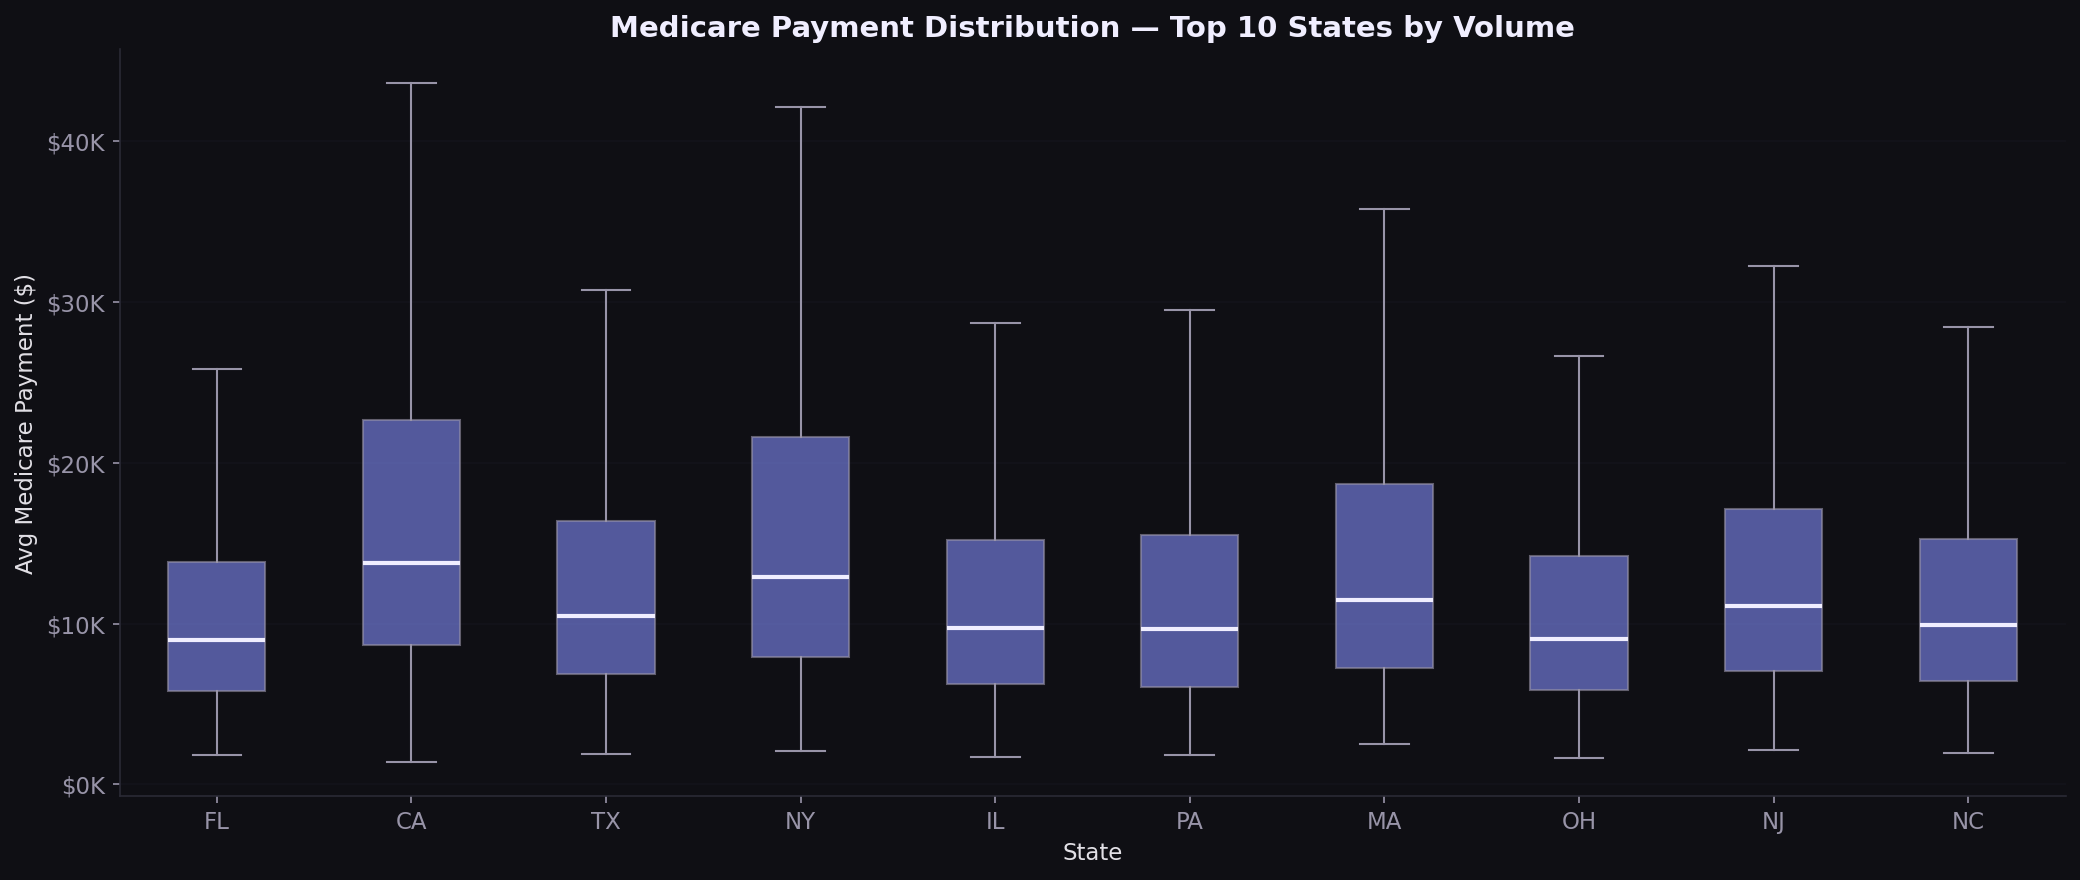

In [7]:
top10_states = state_agg.head(10).index.tolist()
inp_top10 = inp[inp['provider_state'].isin(top10_states)]

fig, ax = plt.subplots(figsize=(14, 6))
data_by_state = [inp_top10[inp_top10['provider_state'] == s]['avg_medicare_payments'].values for s in top10_states]

bp = ax.boxplot(
    data_by_state, labels=top10_states, patch_artist=True, showfliers=False,
    medianprops={'color': '#F0EEFF', 'linewidth': 2},
    whiskerprops={'color': '#9894A8'},
    capprops={'color': '#9894A8'}
)
for patch in bp['boxes']:
    patch.set_facecolor(INDIGO)
    patch.set_alpha(0.6)
    patch.set_edgecolor('#9894A8')

ax.set_ylabel('Avg Medicare Payment ($)')
ax.set_xlabel('State')
ax.set_title('Medicare Payment Distribution — Top 10 States by Volume', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'state_payment_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Physician: top 15 specialties by service volume

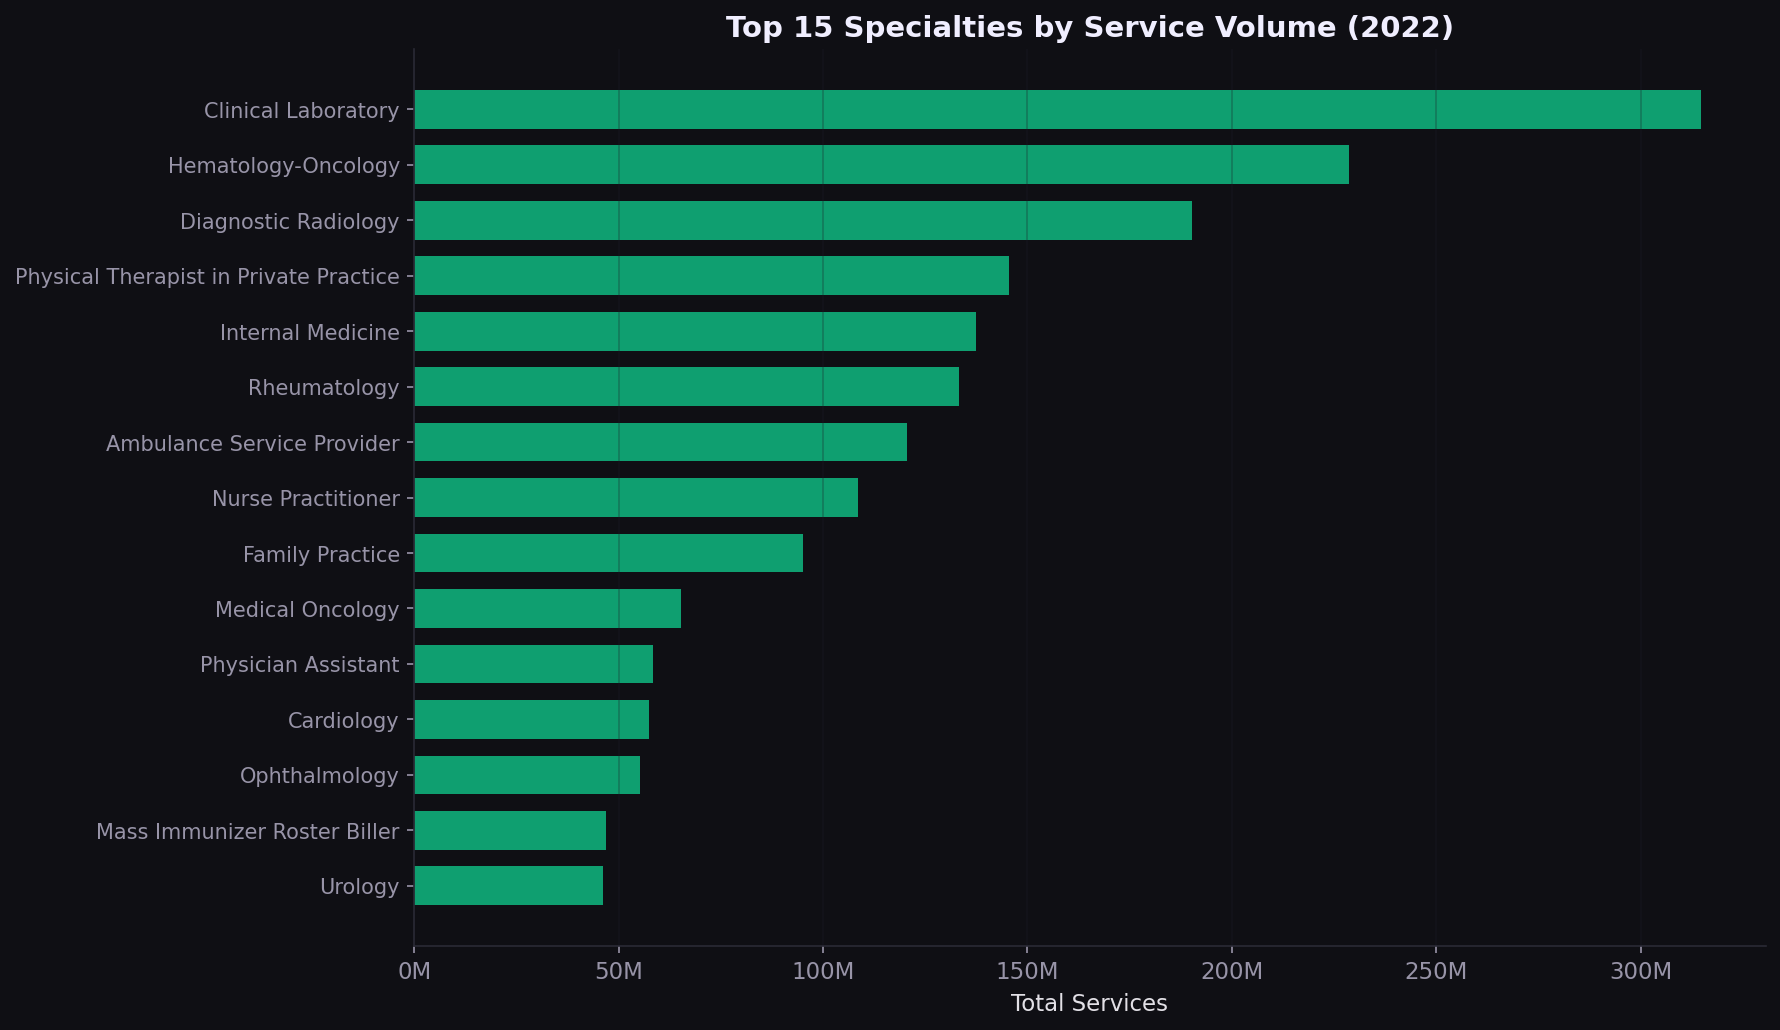

In [8]:
spec_vol = (
    phy.groupby('provider_type')['total_services']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(spec_vol)), spec_vol.values, color=GREEN, alpha=0.85, height=0.7)
ax.set_yticks(range(len(spec_vol)))
ax.set_yticklabels(spec_vol.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Total Services')
ax.set_title('Top 15 Specialties by Service Volume (2022)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'top15_specialty_volume.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Physician: avg payment by specialty (top 15 costliest)

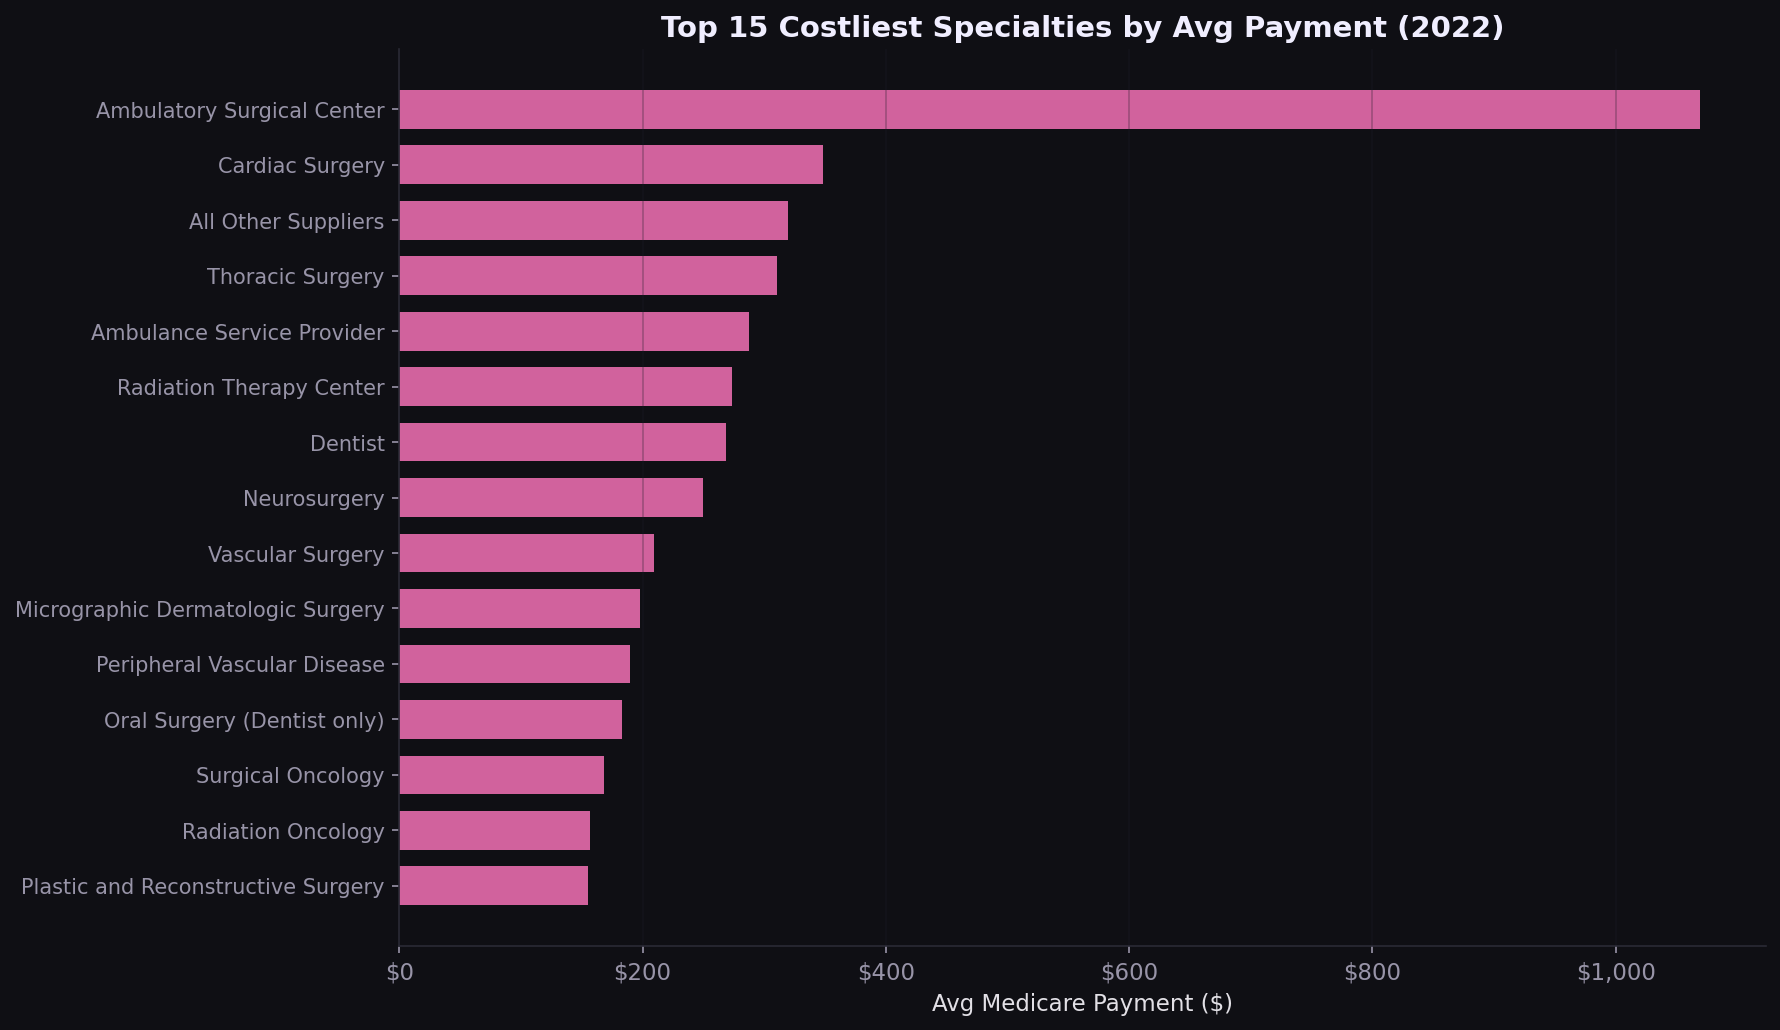

In [9]:
spec_cost = (
    phy.groupby('provider_type')
    .agg(avg_payment=('avg_medicare_payment', 'mean'), total_svc=('total_services', 'sum'))
    .query('total_svc >= 10000')
    .sort_values('avg_payment', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(spec_cost)), spec_cost['avg_payment'], color=PINK, alpha=0.85, height=0.7)
ax.set_yticks(range(len(spec_cost)))
ax.set_yticklabels(spec_cost.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Avg Medicare Payment ($)')
ax.set_title('Top 15 Costliest Specialties by Avg Payment (2022)', fontsize=14, fontweight='bold', color='#F0EEFF')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES / 'top15_specialty_cost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary
| Figure | File |
|--------|------|
| Top 15 DRGs by volume | `top15_drg_volume.png` |
| Top 15 costliest DRGs | `top15_drg_cost.png` |
| DRG markup ratios | `drg_markup_ratios.png` |
| State volume + payment | `state_volume_payment.png` |
| State payment box plot | `state_payment_boxplot.png` |
| Top specialties by volume | `top15_specialty_volume.png` |
| Top specialties by cost | `top15_specialty_cost.png` |